# ART calculations for `Bacillus Anthracis` bacteria

### Training data base `Pubchem + chEMBL`

In [26]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
sys.path.append(".")
sys.path.append('/users/sghosh6/DTRA_project/MACAW/AutomatedRecommendationTool')

import warning_utils
warning_utils.filter_end_user_warnings()

In [60]:
import pandas as pd
import numpy as np
from rdkit import Chem

from art.core import RecommendationEngine
from art.plot import predictions_vs_observations, predictions_distr_vs_observations
import art.utility as utils
import pickle
import cloudpickle
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import gc

### Define directories

In [38]:
dataDir = '/users/sghosh6/DTRA_project/MACAW/DTRA_ART/'
modelBuildingDataDir = os.path.join(dataDir + '/DrugDesignData/modelBuildingData/')
#resultsDir = os.path.join(dataDir, 'Results/')
artResultDir = dataDir + '/ART_CommandLine/BacillusAnthracis_allDB/ART_results'
os.makedirs(artResultDir, exist_ok=True)
saveDir = os.path.join(dataDir + "/DrugDesignData/Results/Bacillus_anthracis_bestMACAW_allDB/")
os.makedirs(saveDir, exist_ok=True)

### Extract the data for `Bacillus Anthracis` into a data frame with `duplicate` SMILES

In [29]:
BacillusAnthracisData_allDB_wMACAW = pd.read_csv(modelBuildingDataDir + "BacillusAnthracisData_allDB_wMACAW.csv")
BacillusAnthracisData_allDB_wMACAW 

,ID,compound_id,Smiles,pPotency,BacteriaClassifier,canonical_smiles,pPotency_category,MACAW_1,MACAW_2,MACAW_3,...,MACAW_81,MACAW_82,MACAW_83,MACAW_84,MACAW_85,MACAW_86,MACAW_87,MACAW_88,MACAW_89,MACAW_90
0,1,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186,Bacillus_anthracis,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,3-10,-0.021547,-0.087225,0.021404,...,-0.010272,0.012309,-0.017448,-0.000035,-0.014912,-0.026106,0.039952,-0.011383,-0.034568,0.032935
1,2,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095,Bacillus_anthracis,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,3-10,0.066620,-0.243946,0.022669,...,-0.011253,-0.002448,-0.014319,0.007077,-0.005703,-0.003603,-0.061587,0.031002,-0.030319,0.038735
2,3,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608,Bacillus_anthracis,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,3-10,0.055315,-0.163706,0.092076,...,0.048354,0.053849,0.025467,-0.001511,0.048082,-0.022568,-0.070715,0.087138,0.120848,-0.035076
3,4,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818,Bacillus_anthracis,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,3-10,0.066620,-0.243946,0.022669,...,-0.011253,-0.002448,-0.014319,0.007077,-0.005703,-0.003603,-0.061587,0.031002,-0.030319,0.038735
4,5,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996,Bacillus_anthracis,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,3-10,0.055315,-0.163706,0.092076,...,0.048354,0.053849,0.025467,-0.001511,0.048082,-0.022568,-0.070715,0.087138,0.120848,-0.035076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4076,4150,CHEMBL560502,CCCC1c2ccccc2C=NN1C(=O)/C=C/c1cc(Cc2cnc(N)nc2N...,7.267606,Bacillus_anthracis,CCCC1c2ccccc2C=NN1C(=O)/C=C/c1cc(Cc2cnc(N)nc2N...,3-10,-0.073695,-0.201158,-0.114346,...,0.044484,-0.039231,-0.030087,0.029348,0.022040,0.040301,0.016524,-0.061330,0.016051,0.039127
4077,4151,CHEMBL561523,COc1cc(/C=C2\SC(=S)N(c3cccc(C(F)(F)F)c3)C2=O)c...,4.022276,Bacillus_anthracis,COc1cc(/C=C2\SC(=S)N(c3cccc(C(F)(F)F)c3)C2=O)c...,3-10,0.059926,-0.065624,-0.018792,...,0.024393,-0.018766,-0.012481,-0.070545,0.002283,0.002058,0.031113,-0.036097,0.030267,0.005757
4078,4152,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.000000,Bacillus_anthracis,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,3-10,0.144828,0.009992,0.073558,...,0.030702,-0.005911,-0.050602,-0.036700,0.028052,-0.058443,-0.046005,-0.028516,0.036423,0.021321
4079,4153,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.800000,Bacillus_anthracis,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,3-10,0.159965,-0.099642,0.052330,...,-0.032179,-0.024883,-0.009078,-0.004752,0.002602,-0.007436,-0.022274,0.011908,0.009133,-0.033252


### Prepare data to run `ART` on `Bacillus Anthracis` data with `duplicate` SMILES

#### Find Features and Response

In [30]:
input_var = [col for col in BacillusAnthracisData_allDB_wMACAW.columns if col.startswith('MACAW_')]
print(f"MACAW Embeddings: {len(input_var)}")
print(input_var)

MACAW Embeddings: 90
['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MACAW_58', 'MACAW_59', 'MACAW_60', 'MACAW_61', 'MACAW_62', 'MACAW_63', 'MACAW_64', 'MACAW_65', 'MACAW_66', 'MACAW_67', 'MACAW_68', 'MACAW_69', 'MACAW_70', 'MACAW_71', 'MACAW_72', 'MACAW_73', 'MACAW_74', 'MACAW_75', 'MACAW_76', 'MACAW_77', 'MACAW_78', 'MACAW_79', 'MACAW_80', 'MACAW_81', 'MACAW_82', 'MA

In [31]:
features = BacillusAnthracisData_allDB_wMACAW[input_var].to_numpy()

In [32]:
response_var = ["pPotency"]
print(response_var)

['pPotency']


In [33]:
response = BacillusAnthracisData_allDB_wMACAW[response_var].to_numpy()

### save the data as a EDD style file

In [34]:
utils.save_edd_csv(features, response, input_var, modelBuildingDataDir + 'BacillusAnthracisData_allDB_wMACAW_ARTready.csv', response_var)

### Predict response with ART

In [35]:
BacillusAnthracisData_allDB_wMACAW_ARTready = pd.read_csv(modelBuildingDataDir + "BacillusAnthracisData_allDB_wMACAW_ARTready.csv")
BacillusAnthracisData_allDB_wMACAW_ARTready

,Line Name,Type,0.0
0,0,MACAW_1,-0.021547
1,1,MACAW_1,0.066620
2,2,MACAW_1,0.055315
3,3,MACAW_1,0.066620
4,4,MACAW_1,0.055315
...,...,...,...
371366,4076,pPotency,7.267606
371367,4077,pPotency,4.022276
371368,4078,pPotency,5.000000
371369,4079,pPotency,7.800000


### Define the ART parameters needed for the prediction

In [36]:
art_params = {
    'input_vars': input_var,
    'response_vars': response_var,
    'objective': 'maximize',
    'threshold': 0.2,
    'alpha': 0.5,
    'num_recommendations': 10,
    'max_mcmc_cores': 4,
    'seed': 42,                    
    'output_dir': artResultDir,
    'recommend': False,
    'cross_val': True,
    'num_tpot_models': 2,
}

### Run ART without recommendations but with cross-validations to gauge how generalizable the results are

### Find SHAP values

We will now find which input features are more important by using SHAP analysis. First, lets initialize the library:

define a wrapper function that provides the ART prediction given and input X, for use by the SHAP library

convert the ART input data into the pandas dataframe that the SHAP library favors

create and execute the explainer for the features values

### Load pre-trained ART model (if necessary, otherwise skip this step)

In [39]:
ARTtrainedModelFile = os.path.join(artResultDir, 'art.cpkl')
with open(ARTtrainedModelFile, 'rb') as f:
    art = cloudpickle.load(f)
print(f" ART model loaded from: {ARTtrainedModelFile}")

 ART model loaded from: /users/sghosh6/DTRA_project/MACAW/DTRA_ART//ART_CommandLine/BacillusAnthracis_allDB/ART_results/art.cpkl


### Load pre-trained ART model (if necessary, otherwise skip this step)

ART model loaded from: /users/sghosh6/DTRA_project/MACAW/DTRA_ART//ART_CommandLine/BacillusAnthracis_allDB/ART_results/art.cpkl
ART output directory: /users/sghosh6/DTRA_project/MACAW/DTRA_ART/ART_CommandLine/BacillusAnthracis_allDB/ART_results


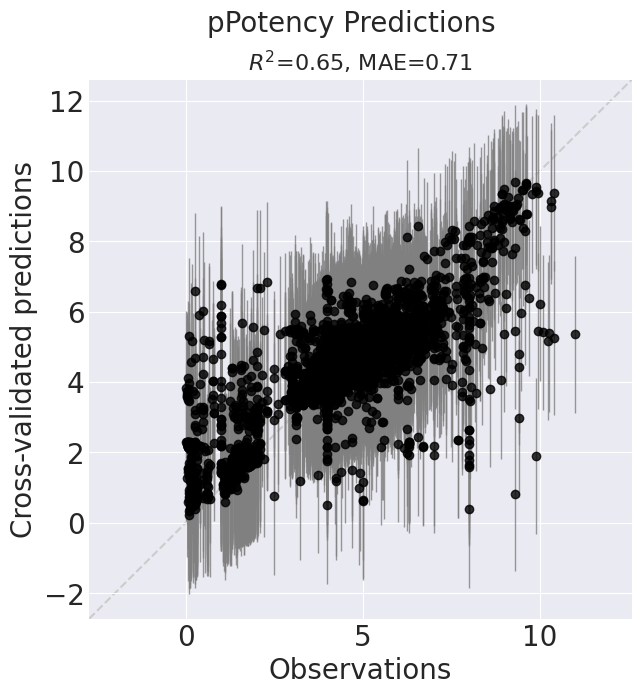

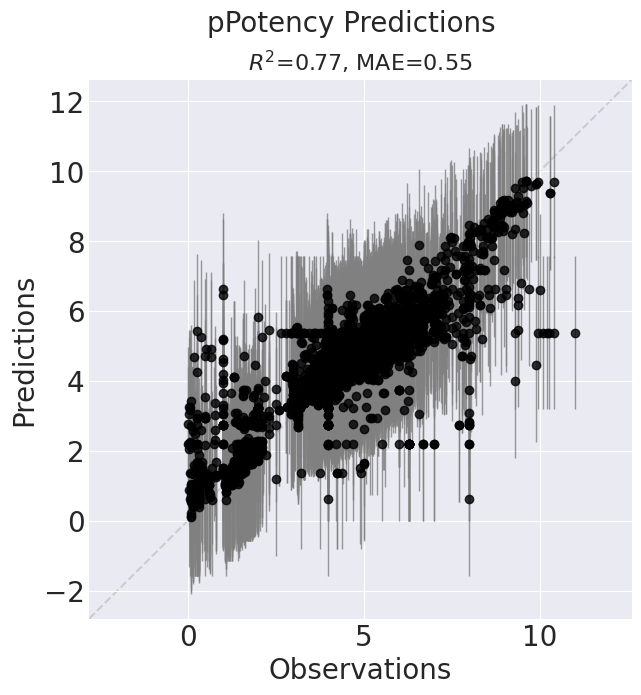

In [44]:
ARTtrainedModelFile = os.path.join(artResultDir, "art.cpkl")
with open(ARTtrainedModelFile, "rb") as f:
    art = cloudpickle.load(f)

print(f"ART model loaded from: {ARTtrainedModelFile}")

# Force ART to use the current result directory
art.output_dir = artResultDir
os.makedirs(art.output_dir, exist_ok=True)

print(f"ART output directory: {art.output_dir}")

# Generate both ART plots
predictions_vs_observations(
    art,
    cv=True,
    error_bars=True
)

predictions_vs_observations(
    art,
    cv=False,
    error_bars=True
)

## 4.Find external validation with pre-trained `ART` models

### 4.1 `All buyable` Antibiotics

In [52]:
BacillusAnthracis_all_Buyable_AntiVirals_wMACAW = pd.read_csv(saveDir + "/BacillusAnthracis_all_Buyable_Antibiotic_wMACAW.csv")

print(f"Total buyable antiviral molecules before removing training set molecules: {len(BacillusAnthracis_all_Buyable_AntiVirals_wMACAW)}")

# Get the set of training SMILES from the chEMBL data for fast lookup
training_smiles_set = set(BacillusAnthracisData_allDB_wMACAW['Smiles'])

# Remove rows whose SMILES are present in the training data
BacillusAnthracis_all_Buyable_AntiVirals_wMACAW = BacillusAnthracis_all_Buyable_AntiVirals_wMACAW[
    ~BacillusAnthracis_all_Buyable_AntiVirals_wMACAW['SMILES'].isin(training_smiles_set)
].reset_index(drop=True)

removed_count = len(training_smiles_set) - (len(training_smiles_set) - (len(BacillusAnthracis_all_Buyable_AntiVirals_wMACAW)))
#print(f"Training set molecules found and removed: {len(pd.read_csv(saveDir + '/Bacillus_anthracis_all_Buyable_AntiVirals_wMACAW.csv')) - len(BacillusAnthracis_all_Buyable_AntiVirals_wMACAW)}")
print(f"Total buyable antiviral molecules for external validation after removing training set molecules: {len(BacillusAnthracis_all_Buyable_AntiVirals_wMACAW)}")

BacillusAnthracis_all_Buyable_AntiVirals_wMACAW

Total buyable antiviral molecules before removing training set molecules: 59738
Total buyable antiviral molecules for external validation after removing training set molecules: 59738


,SMILES,source_DataBase,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,...,MACAW_81,MACAW_82,MACAW_83,MACAW_84,MACAW_85,MACAW_86,MACAW_87,MACAW_88,MACAW_89,MACAW_90
0,Cc1nnc(COC(=O)c2ccc(N3CC(C)CC(C)C3)c([N+](=O)[...,Enamine_Antibiotic,0.001435,0.017110,-0.033992,0.024350,-0.081107,-0.001772,0.007535,0.021145,...,0.021552,0.025465,0.005999,-0.027241,0.008883,0.010454,-0.005293,0.014145,-0.016321,0.001007
1,Cc1nc2nc(SCCCOC(=O)NC(N)=O)nn2c(C)c1C,Enamine_Antibiotic,-0.012327,0.025964,0.021308,0.058131,-0.034940,0.049120,-0.004911,0.088965,...,0.001544,-0.028927,-0.014688,0.019057,-0.008258,-0.020367,0.004434,0.006554,-0.024008,0.002841
2,Cc1ccc(S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC(C)C2)cc1,Enamine_Antibiotic,-0.001142,0.044438,-0.046790,-0.035690,-0.069941,-0.052927,0.007195,0.020632,...,-0.012478,0.003965,0.022483,0.015614,-0.012766,-0.028302,0.028364,-0.043400,-0.021674,0.001514
3,CC(C)n1cnc(S(=O)(=O)Nc2ccn(Cc3ccccn3)n2)c1,Enamine_Antibiotic,0.083770,-0.049112,-0.010303,0.018904,-0.002130,0.016194,0.047359,0.014154,...,-0.015897,0.008499,0.048837,-0.022723,0.036387,0.007081,0.001427,-0.001576,-0.035630,-0.018799
4,O=C(O)Cc1ccc(S(=O)(=O)Nc2ccc(Cl)cc2O)cc1,Enamine_Antibiotic,0.059512,0.008561,0.101127,0.020102,0.060101,-0.114396,0.101967,-0.007367,...,0.009948,-0.026679,0.013907,-0.005756,-0.020904,0.011521,0.009147,-0.008717,-0.015619,0.008566
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59733,Nc1nc(Nc2ccccc2F)nc2ccccc12,ChemDiv_Antibiotic,0.163185,-0.058308,0.073991,0.078411,0.042407,-0.002301,0.067346,0.011869,...,-0.033358,-0.032075,-0.007888,0.000141,0.040299,-0.008839,-0.012512,0.012618,-0.003058,0.018393
59734,CNc1nc(Nc2ccccc2F)nc2ccccc12,ChemDiv_Antibiotic,0.174060,-0.069772,0.065263,0.035339,0.044385,-0.015512,0.061554,0.044698,...,-0.036973,-0.006712,-0.011899,0.003493,0.040843,-0.009737,-0.014748,0.028099,-0.006564,0.008398
59735,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,ChemDiv_Antibiotic,0.168254,-0.068934,0.064322,0.089236,0.040839,0.005925,0.085738,0.001270,...,-0.023377,-0.028428,-0.003953,-0.011790,0.046125,-0.015678,-0.021167,0.034193,-0.003404,0.003440
59736,CNc1nc(Nc2ccccc2Cl)nc2ccccc12,ChemDiv_Antibiotic,0.181616,-0.085079,0.052871,0.041824,0.043082,-0.008824,0.072623,0.038280,...,-0.024777,-0.008163,-0.012032,-0.013077,0.038844,-0.014057,-0.019539,0.040393,-0.002109,0.001956


In [53]:
macaw_columns = [col for col in BacillusAnthracis_all_Buyable_AntiVirals_wMACAW.columns if col.startswith('MACAW_')]
smiLib = BacillusAnthracis_all_Buyable_AntiVirals_wMACAW[macaw_columns].values

### Get predictions with uncertainty using ART's post_pred_stats

In [54]:
# Pass X1_lib (features)
mean, std = art.post_pred_stats(smiLib)

# Now use these for your results
BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction = BacillusAnthracis_all_Buyable_AntiVirals_wMACAW[['SMILES']].copy()
BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction['pPotency_prediction'] = mean
BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction['pPotency_std'] = std

# Calculate 95% Confidence Intervals
BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction['pPotency_lower_95CI'] = mean - 1.96 * std
BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction['IC50(M)_prediction'] = 10 ** (-mean)
BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction['IC50(M)_lower_95CI'] = 10 ** (-BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction['pPotency_upper_95CI'])
BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction['IC50(M)_upper_95CI'] = 10 ** (-BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction['pPotency_lower_95CI'])

# Select and save results
BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction = BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction.filter(
    items=["SMILES", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction.to_csv(os.path.join(saveDir + "/BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction.csv"), index=False)
BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction[['SMILES']].to_csv(os.path.join(saveDir + "/BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction_SMILES.csv"), index=False)
print(f"Predictions saved with uncertainty estimates")
BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction

Predictions saved with uncertainty estimates


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Cc1nnc(COC(=O)c2ccc(N3CC(C)CC(C)C3)c([N+](=O)[...,4.169872,1.119030,1.976573,6.363170,0.000068,4.333413e-07,0.010554
1,Cc1nc2nc(SCCCOC(=O)NC(N)=O)nn2c(C)c1C,4.429163,1.118621,2.236666,6.621661,0.000037,2.389674e-07,0.005799
2,Cc1ccc(S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC(C)C2)cc1,4.621105,1.118405,2.429031,6.813180,0.000024,1.537519e-07,0.003724
3,CC(C)n1cnc(S(=O)(=O)Nc2ccn(Cc3ccccn3)n2)c1,4.521367,1.120633,2.324927,6.717807,0.000030,1.915106e-07,0.004732
4,O=C(O)Cc1ccc(S(=O)(=O)Nc2ccc(Cl)cc2O)cc1,4.643503,1.119350,2.449576,6.837430,0.000023,1.454020e-07,0.003552
...,...,...,...,...,...,...,...,...
59733,Nc1nc(Nc2ccccc2F)nc2ccccc12,4.008815,1.118924,1.815724,6.201907,0.000098,6.281934e-07,0.015285
59734,CNc1nc(Nc2ccccc2F)nc2ccccc12,4.196679,1.119485,2.002488,6.390870,0.000064,4.065651e-07,0.009943
59735,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,4.423288,1.119218,2.229622,6.616955,0.000038,2.415712e-07,0.005894
59736,CNc1nc(Nc2ccccc2Cl)nc2ccccc12,4.833275,1.121137,2.635845,7.030704,0.000015,9.317435e-08,0.002313


### 4.2 `DORAnet Generated Antibiotic:` Find external validation with pre-trained `ART` models

In [57]:
def canonicalize(smi):
    mol = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(mol) if mol else smi

# Load DORAnet generated molecules
BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_wMACAW = pd.read_csv(
    saveDir + "/BacillusAnthracisData_basidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW.csv")

total_before = len(BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_wMACAW)
print(f"Total DORAnet generated molecules before removing training set molecules: {total_before}")

# Training set stats
total_training_rows = len(BacillusAnthracisData_allDB_wMACAW)
unique_training_smiles = BacillusAnthracisData_allDB_wMACAW['Smiles'].nunique()
duplicate_training_smiles = BacillusAnthracisData_allDB_wMACAW['Smiles'].duplicated().sum()
print(f"Total training set SMILES: {total_training_rows}")
print(f"Unique training set SMILES: {unique_training_smiles}")
print(f"Duplicate training set SMILES: {duplicate_training_smiles}")

# Canonicalize training SMILES for consistent matching
training_smiles_set = set(BacillusAnthracisData_allDB_wMACAW['Smiles'].apply(canonicalize))
print(f"Unique canonical training SMILES: {len(training_smiles_set)}")

# Canonicalize DORAnet SMILES and remove matches
BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_wMACAW['canonical_SMILES'] = \
    BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_wMACAW['SMILES'].apply(canonicalize)

BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_wMACAW = \
    BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_wMACAW[
        ~BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_wMACAW['canonical_SMILES'].isin(training_smiles_set)
    ].drop(columns=['canonical_SMILES']).reset_index(drop=True)

total_after = len(BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_wMACAW)
print(f"\nTraining set molecules found and removed: {total_before - total_after}")
print(f"Total DORAnet generated molecules for external validation: {total_after}")

BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_wMACAW

Total DORAnet generated molecules before removing training set molecules: 651812
Total training set SMILES: 4081
Unique training set SMILES: 1647
Duplicate training set SMILES: 2434
Unique canonical training SMILES: 1647

Training set molecules found and removed: 2
Total DORAnet generated molecules for external validation: 651810


,SMILES,Is_Starter,SourceDirectories,source_DataBase,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,...,MACAW_81,MACAW_82,MACAW_83,MACAW_84,MACAW_85,MACAW_86,MACAW_87,MACAW_88,MACAW_89,MACAW_90
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor,-0.018789,0.052680,-0.092646,0.075939,-0.029722,0.099382,...,-0.043605,0.011595,0.020968,0.002319,-0.017124,-0.012887,0.001690,0.006866,-0.030586,0.054283
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor,0.050514,0.098763,-0.042017,0.124382,-0.072359,0.192675,...,-0.000678,0.006703,0.002601,0.011888,-0.025438,-0.016349,-0.001066,0.012871,-0.041962,0.025024
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor,-0.134476,-0.000647,-0.219158,0.054282,0.089899,0.011588,...,-0.031160,0.008215,0.001953,-0.000030,0.018431,-0.005266,-0.002801,-0.007540,0.009168,0.023692
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor,-0.141337,-0.001813,-0.223714,0.046393,0.094416,0.006969,...,-0.034302,0.010502,0.004411,0.005599,0.021522,-0.007535,-0.003053,-0.005525,0.018530,0.022488
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor,0.008330,0.069893,-0.059470,0.091975,-0.055415,0.147296,...,-0.021016,0.004138,0.005148,0.012217,-0.011156,-0.012812,-0.006275,0.010243,-0.034544,0.044004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
651805,C[C@H](N)CC1=C(O)C(=O)OC1=C[C@@H](C)CNC=O,False,starter_02053,basidalin_Precursor,0.073188,0.105300,0.027018,-0.015211,-0.014812,-0.028660,...,-0.005769,0.026173,0.005067,0.020617,0.007581,0.022723,-0.016983,-0.025612,-0.011230,0.008497
651806,Cc1c(O)c2oc1=C[C@@H](C)CNC(=O)[C@H](C)N=2,False,starter_02053,basidalin_Precursor,0.119939,0.075045,0.015621,0.003091,-0.001189,-0.001738,...,0.010226,-0.020294,-0.002550,-0.029394,0.007379,0.007547,-0.001703,-0.023207,-0.003234,0.013521
651807,C[C@H](C=C1OC(=O)C2=C1CO2)CNC(O)[C@H](C)N,False,starter_02053,basidalin_Precursor,0.052331,0.108792,-0.013783,0.010239,-0.071023,0.024446,...,-0.002547,-0.000251,0.003120,0.002177,0.008981,0.023754,-0.003137,-0.034606,-0.013534,0.007562
651808,CC1=C2O[C@](C)(N)C(O)NC[C@H](C)C=C1OC2=O,False,starter_02053,basidalin_Precursor,0.089309,0.090954,-0.014077,0.012497,-0.023413,0.018071,...,0.015972,-0.004717,-0.003708,-0.017070,0.018867,0.006971,-0.016886,-0.032889,-0.001460,-0.000007


In [ ]:
macaw_columns = [col for col in BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_wMACAW.columns if col.startswith('MACAW_')]
smiLib = BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_wMACAW[macaw_columns].values

### Get predictions with uncertainty using ART's post_pred_stats

In [58]:
chunk_size = 100000
total_rows = len(BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_wMACAW)
print(f"Total molecules to predict: {total_rows}")
print(f"Processing in chunks of {chunk_size}...")

macaw_cols = [col for col in BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_wMACAW.columns if col.startswith('MACAW_')]

output_path = os.path.join(saveDir, "BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_ARTprediction.csv")
smiles_output_path = os.path.join(saveDir, "BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_ARTprediction_SMILESonly.csv")

if os.path.exists(output_path):
    os.remove(output_path)
if os.path.exists(smiles_output_path):
    os.remove(smiles_output_path)

header_written = False

for start in range(0, total_rows, chunk_size):
    end = min(start + chunk_size, total_rows)
    print(f"  Processing chunk {start} - {end} ({end}/{total_rows})...")

    chunk_features = BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_wMACAW.iloc[start:end][macaw_cols].values
    chunk_smiles = BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_wMACAW.iloc[start:end]['SMILES'].values
    chunk_is_starter = BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_wMACAW.iloc[start:end]['Is_Starter'].values
    chunk_source_dirs = BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_wMACAW.iloc[start:end]['source_DataBase'].values

    mean, std = art.post_pred_stats(chunk_features)
    mean = np.array(mean).flatten()
    std = np.array(std).flatten()

    chunk_df = pd.DataFrame({
        'SMILES': chunk_smiles,
        'Is_Starter': chunk_is_starter,
        'SourceDirectories': chunk_source_dirs,
        'pPotency_prediction': mean,
        'pPotency_std': std,
        'pPotency_lower_95CI': mean - 1.96 * std,
        'pPotency_upper_95CI': mean + 1.96 * std,
        'IC50(M)_prediction': 10 ** (-mean),
        'IC50(M)_lower_95CI': 10 ** (-(mean + 1.96 * std)),
        'IC50(M)_upper_95CI': 10 ** (-(mean - 1.96 * std)),
    })

    chunk_df.to_csv(output_path, mode='a', header=not header_written, index=False)
    chunk_df[['SMILES']].to_csv(smiles_output_path, mode='a', header=not header_written, index=False)
    header_written = True

    del chunk_features, chunk_smiles, chunk_is_starter, chunk_source_dirs, mean, std, chunk_df
    gc.collect()

print(f"\nPredictions saved to: {output_path}")
print(f"SMILES-only saved to: {smiles_output_path}")

BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_ARTprediction = pd.read_csv(output_path)
print(f"Total predictions: {len(BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_ARTprediction)}")
BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_ARTprediction.head()

Total molecules to predict: 651810
Processing in chunks of 100000...
  Processing chunk 0 - 100000 (100000/651810)...
  Processing chunk 100000 - 200000 (200000/651810)...
  Processing chunk 200000 - 300000 (300000/651810)...
  Processing chunk 300000 - 400000 (400000/651810)...
  Processing chunk 400000 - 500000 (500000/651810)...
  Processing chunk 500000 - 600000 (600000/651810)...
  Processing chunk 600000 - 651810 (651810/651810)...

Predictions saved to: /users/sghosh6/DTRA_project/MACAW/DTRA_ART//DrugDesignData/Results/Bacillus_anthracis_bestMACAW_allDB/BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_ARTprediction.csv
SMILES-only saved to: /users/sghosh6/DTRA_project/MACAW/DTRA_ART//DrugDesignData/Results/Bacillus_anthracis_bestMACAW_allDB/BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_ARTprediction_SMILESonly.csv
Total predictions: 651810


,SMILES,Is_Starter,SourceDirectories,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,basidalin_Precursor,5.331199,1.119903,3.136188,7.526210,0.000005,2.977075e-08,0.000731
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,basidalin_Precursor,3.626339,1.118850,1.433394,5.819284,0.000236,1.516058e-06,0.036864
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,basidalin_Precursor,4.428906,1.118935,2.235793,6.622019,0.000037,2.387706e-07,0.005810
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,basidalin_Precursor,4.461134,1.118921,2.268049,6.654220,0.000035,2.217075e-07,0.005394
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,basidalin_Precursor,4.480122,1.118720,2.287430,6.672814,0.000033,2.124154e-07,0.005159


### Plot prediction probability

Molecule 1: mean=5.347, std=1.133, 95% CI=[3.191, 7.555], IC50=4.5014 µM
Molecule 2: mean=5.283, std=1.120, 95% CI=[3.093, 7.453], IC50=5.2105 µM
Molecule 3: mean=5.164, std=1.118, 95% CI=[3.022, 7.367], IC50=6.8610 µM
Molecule 4: mean=5.161, std=1.114, 95% CI=[3.007, 7.347], IC50=6.9018 µM
Molecule 5: mean=5.124, std=1.100, 95% CI=[3.051, 7.285], IC50=7.5231 µM
Molecule 6: mean=5.029, std=1.117, 95% CI=[2.802, 7.219], IC50=9.3486 µM
Molecule 7: mean=5.030, std=1.118, 95% CI=[2.815, 7.179], IC50=9.3390 µM
Molecule 8: mean=5.019, std=1.121, 95% CI=[2.801, 7.183], IC50=9.5668 µM
Molecule 9: mean=5.072, std=1.117, 95% CI=[2.846, 7.192], IC50=8.4671 µM
Molecule 10: mean=5.045, std=1.129, 95% CI=[2.813, 7.235], IC50=9.0180 µM
Molecule 11: mean=5.033, std=1.135, 95% CI=[2.804, 7.299], IC50=9.2579 µM
Molecule 12: mean=5.028, std=1.123, 95% CI=[2.827, 7.216], IC50=9.3657 µM
Molecule 13: mean=5.062, std=1.136, 95% CI=[2.787, 7.304], IC50=8.6725 µM
Molecule 14: mean=5.027, std=1.123, 95% CI=[2.8

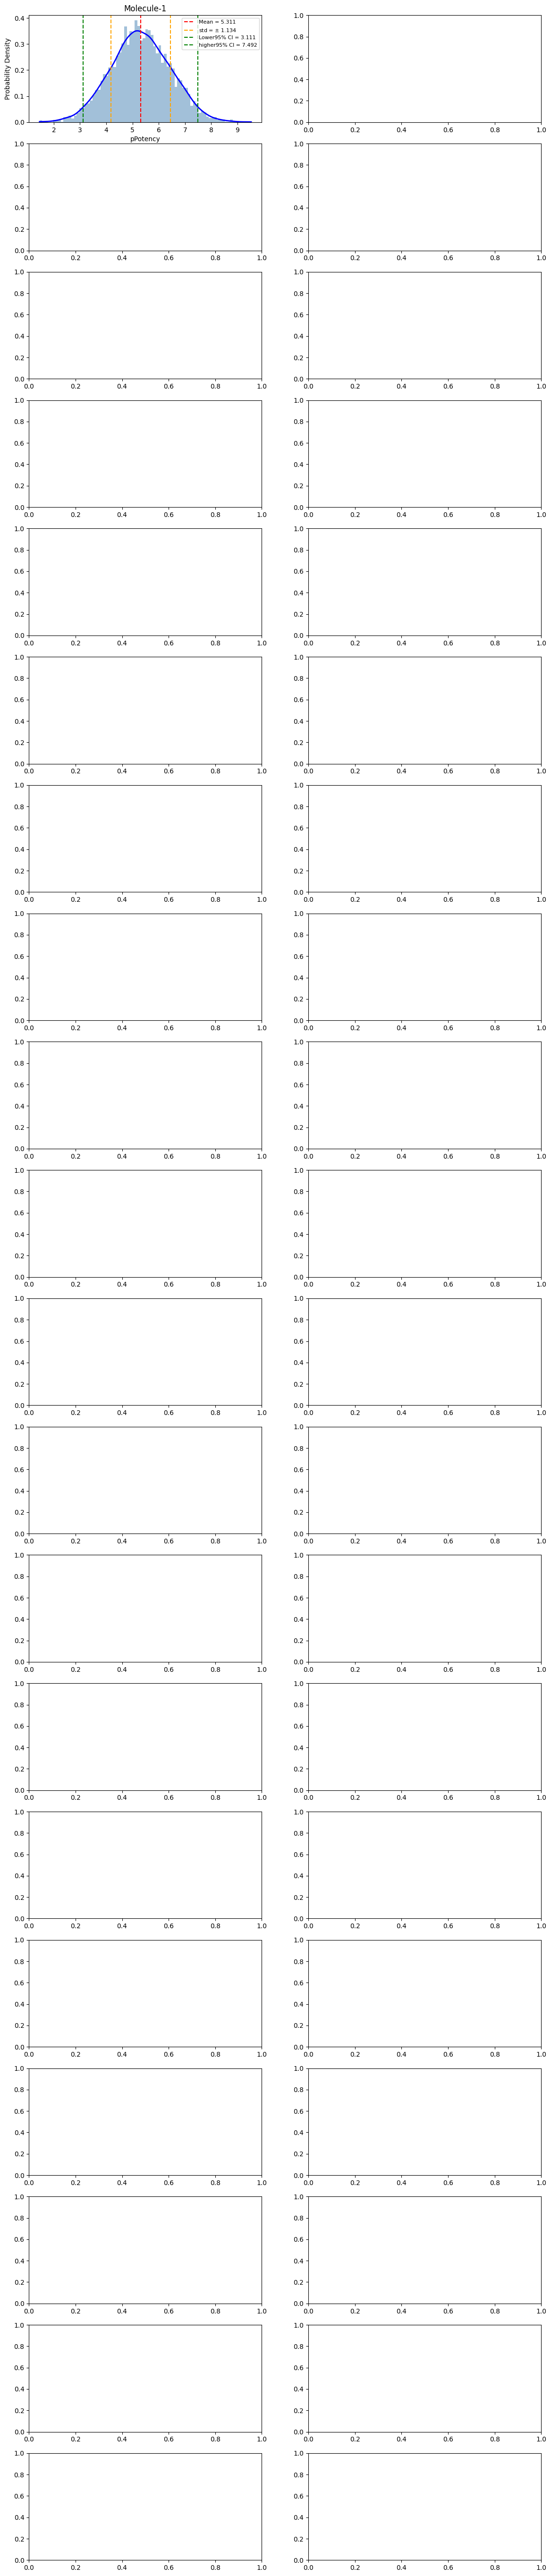

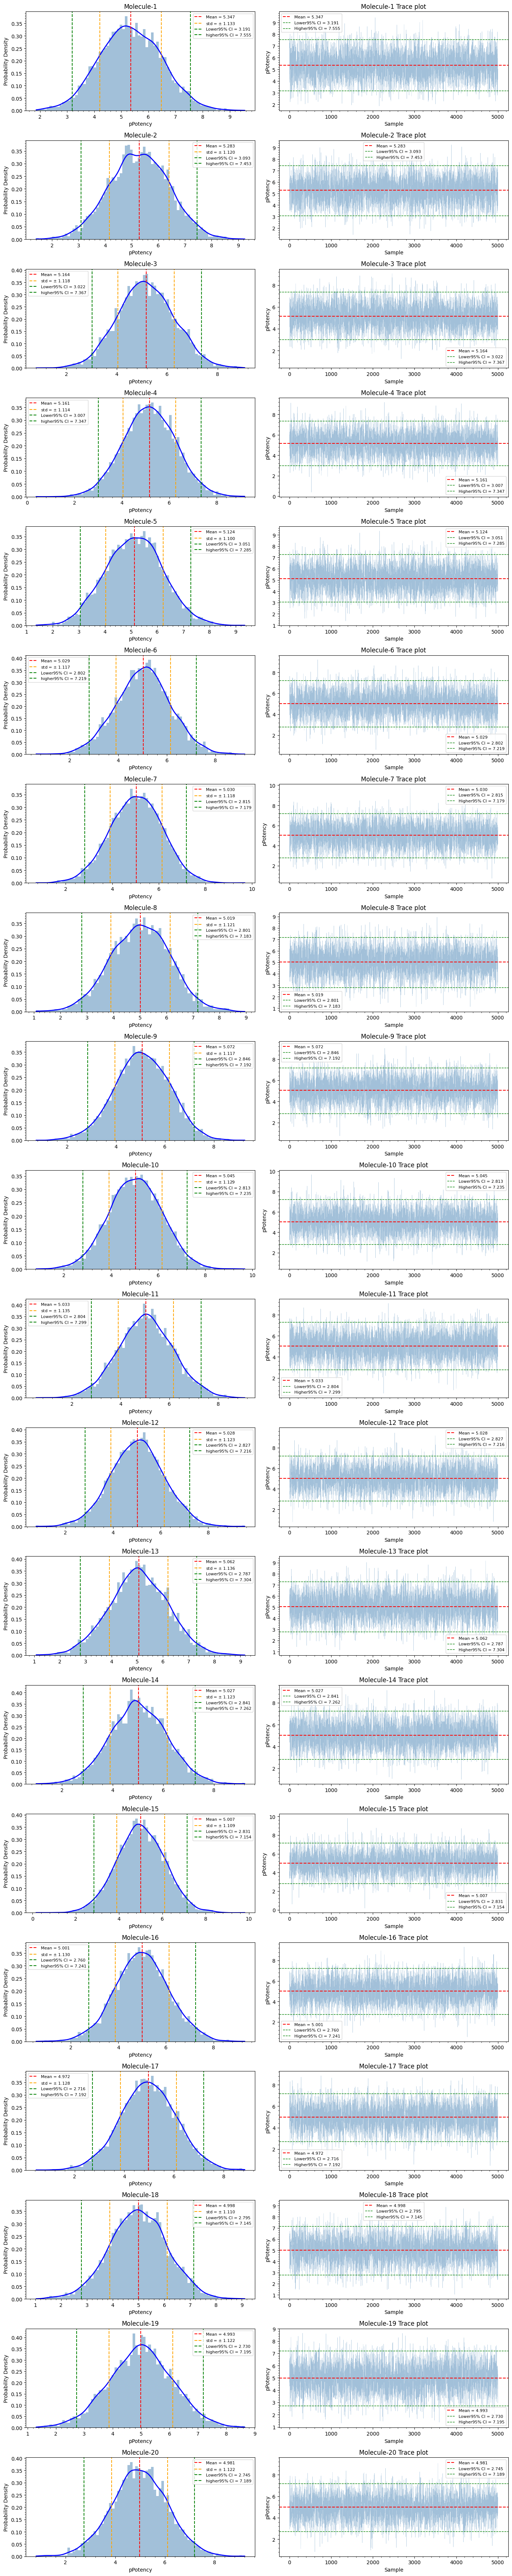

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_potency_from_draws(pred_df, feat_df, art, n=5, n_samples=5000):
    macaw_cols = [c for c in feat_df.columns if c.startswith('MACAW_')]

    merged = (
        pred_df.nlargest(n, 'pPotency_prediction')
               .merge(feat_df[['SMILES', *macaw_cols]], on='SMILES', how='inner')
    )
    if merged.empty:
        raise ValueError("None of the top‑n molecules have matching MACAW features.")

    fig, axes = plt.subplots(len(merged), 2, figsize=(14, 3.5 * len(merged)), squeeze=False)

    for i, (_, row) in enumerate(merged.iterrows()):
        x = row[macaw_cols].to_numpy(dtype=float).reshape(1, -1)

        raw_draws = art.post_pred_draws(x, n_samples=n_samples)
        draws = np.asarray(raw_draws).ravel()
        if draws.size < 2:
            print(f"Skipping {row['SMILES']} (not enough posterior samples).")
            continue

        mean = draws.mean()
        std = draws.std()
        lower_95, upper_95 = np.percentile(draws, [2.5, 97.5])

        

        ax_dist = axes[i, 0]
        ax_dist.hist(draws, bins=min(80, len(draws)//2 or 1), density=True,
                     alpha=0.5, color='steelblue')
        try:
            kde = gaussian_kde(draws)
            x_range = np.linspace(draws.min(), draws.max(), 500)
            ax_dist.plot(x_range, kde(x_range), 'b-', lw=2)
        except np.linalg.LinAlgError:
            pass  # KDE fails when draws have zero variance
        ax_dist.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.3f}')
        ax_dist.axvline(mean - std, color='orange', linestyle='--', lw=1.5)
        ax_dist.axvline(mean + std, color='orange', linestyle='--', lw=1.5, label=fr'std = $\pm$ {std:.3f}')
        ax_dist.axvline(lower_95, color='green', linestyle='--', label=f'Lower95% CI = {lower_95:.3f}')
        ax_dist.axvline(upper_95, color='green', linestyle='--', label=f'higher95% CI = {upper_95:.3f}')
        ax_dist.set_xlabel('pPotency')
        ax_dist.set_ylabel('Probability Density')
        ax_dist.set_title(f"Molecule-{i+1}")
        

        

        ax_dist.legend(fontsize=8, frameon=True)
        ax_dist.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_dist.yaxis.set_minor_locator(AutoMinorLocator(5))

        ax_trace = axes[i, 1]
        ax_trace.plot(draws, alpha=0.5, lw=0.3, color='steelblue')
        ax_trace.axhline(mean, color='red', linestyle='--', lw=1.5, label=f'Mean = {mean:.3f}')
        ax_trace.axhline(lower_95, color='green', linestyle='--', lw=1, label=f'Lower95% CI = {lower_95:.3f}')
        ax_trace.axhline(upper_95, color='green', linestyle='--', lw=1, label=f'Higher95% CI = {upper_95:.3f}')
        ax_trace.set_xlabel('Sample')
        ax_trace.set_ylabel('pPotency')
        ax_trace.set_title(f"Molecule-{i+1} Trace plot")
        ax_trace.legend(fontsize=8, frameon=True)
        ax_trace.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_trace.yaxis.set_minor_locator(AutoMinorLocator(5))

        print(f"Molecule {i+1}: mean={mean:.3f}, std={std:.3f}, "
              f"95% CI=[{lower_95:.3f}, {upper_95:.3f}], "
              f"IC50={10**(-mean)*1e6:.4f} µM")

    plt.tight_layout()
    plt.savefig(os.path.join(saveDir, "BacillusAnthracis_BasidalinPrecursor_ARTprobability.png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(saveDir, "BacillusAnthracis_BasidalinPrecursor_ARTprobability.pdf"), dpi=300, bbox_inches="tight")
    plt.show()

# plot potency of top 20 recomended molecules
plot_potency_from_draws(
    pred_df=BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_ARTprediction,
    feat_df=BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_wMACAW,
    art=art,
    n=20,
    n_samples=5000
)


### 2.3 Checking drug likeliness of `Basidalin`

In [62]:
BacillusAnthracis_DTRA_target_AntiBiotic_wMACAW = pd.read_csv(saveDir + "BacillusAnthracisData_DTRA_target_Antibiotic_SMILES_wMACAW.csv")
BacillusAnthracis_DTRA_target_AntiBiotic_wMACAW

,Drug_Name,SMILES,Molecular_Formula,Molecular_Weight,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,...,MACAW_81,MACAW_82,MACAW_83,MACAW_84,MACAW_85,MACAW_86,MACAW_87,MACAW_88,MACAW_89,MACAW_90
0,Basidalin,C1=C(/C(=C\C=O)/OC1=O)N,C6H5NO3,139.11,0.152011,0.109215,0.031511,0.073136,0.084148,-0.020589,...,-0.013146,0.01346,0.017459,0.017143,-0.00731,-0.008266,-0.008189,0.010506,-0.001699,-0.006967


In [63]:
macaw_columns = [col for col in BacillusAnthracis_DTRA_target_AntiBiotic_wMACAW.columns if col.startswith('MACAW_')]
smi_lib_DTRA_target_AntiBiotic_wMACAW = BacillusAnthracis_DTRA_target_AntiBiotic_wMACAW[macaw_columns].values

Get predictions with uncertainty using ART's post_pred_stats

In [64]:
# Pass X1_lib (features)
mean, std = art.post_pred_stats(smi_lib_DTRA_target_AntiBiotic_wMACAW)

# Now use these for your results
DTRA_target_AntiBiotic_predicted = BacillusAnthracis_DTRA_target_AntiBiotic_wMACAW[['SMILES']].copy()
DTRA_target_AntiBiotic_predicted['pPotency_prediction'] = mean
DTRA_target_AntiBiotic_predicted['pPotency_std'] = std

# Calculate 95% Confidence Intervals
DTRA_target_AntiBiotic_predicted['pPotency_lower_95CI'] = mean - 1.96 * std
DTRA_target_AntiBiotic_predicted['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
DTRA_target_AntiBiotic_predicted['IC50(M)_prediction'] = 10 ** (-mean)
DTRA_target_AntiBiotic_predicted['IC50(M)_lower_95CI'] = 10 ** (-DTRA_target_AntiBiotic_predicted['pPotency_upper_95CI'])
DTRA_target_AntiBiotic_predicted['IC50(M)_upper_95CI'] = 10 ** (-DTRA_target_AntiBiotic_predicted['pPotency_lower_95CI'])

# Select and save results
DTRA_target_AntiBiotic_predicted = DTRA_target_AntiBiotic_predicted.filter(
    items=["SMILES", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

DTRA_target_AntiBiotic_predicted.to_csv(os.path.join(saveDir + "BacillusAnthracisData_DTRA_target_Antibiotic_ARTprediction.csv"), index=False)
DTRA_target_AntiBiotic_predicted[['SMILES']].to_csv(os.path.join(saveDir + "BacillusAnthracisData_DTRA_target_Antibiotic_ARTprediction_SMILES.csv"), index=False)
print(f"Predictions saved with uncertainty estimates")
DTRA_target_AntiBiotic_predicted

Predictions saved with uncertainty estimates


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,C1=C(/C(=C\C=O)/OC1=O)N,3.620342,1.119186,1.426739,5.813946,0.00024,0.000002,0.037434


### 4.4 `Basidalin only` DORAnet Generated Antibiotic: Find external validation with pre-trained `ART` models

In [65]:
def canonicalize(smi):
    mol = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(mol) if mol else smi

# Load DORAnet generated molecules
BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_wMACAW = pd.read_csv(
    saveDir + "/BacillusAnthracisData_basidalinOnly_DORAnetGenerated_Antibiotic_wMACAW.csv")

total_before = len(BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_wMACAW)
print(f"Total DORAnet generated molecules before removing training set molecules: {total_before}")

# Training set stats
total_training_rows = len(BacillusAnthracisData_allDB_wMACAW)
unique_training_smiles = BacillusAnthracisData_allDB_wMACAW['Smiles'].nunique()
duplicate_training_smiles = BacillusAnthracisData_allDB_wMACAW['Smiles'].duplicated().sum()
print(f"Total training set SMILES: {total_training_rows}")
print(f"Unique training set SMILES: {unique_training_smiles}")
print(f"Duplicate training set SMILES: {duplicate_training_smiles}")

# Canonicalize training SMILES for consistent matching
training_smiles_set = set(BacillusAnthracisData_allDB_wMACAW['Smiles'].apply(canonicalize))
print(f"Unique canonical training SMILES: {len(training_smiles_set)}")

# Canonicalize DORAnet SMILES and remove matches
BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_wMACAW['canonical_SMILES'] = \
    BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_wMACAW['SMILES'].apply(canonicalize)

BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_wMACAW = \
    BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_wMACAW[
        ~BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_wMACAW['canonical_SMILES'].isin(training_smiles_set)
    ].drop(columns=['canonical_SMILES']).reset_index(drop=True)

total_after = len(BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_wMACAW)
print(f"\nTraining set molecules found and removed: {total_before - total_after}")
print(f"Total DORAnet generated molecules for external validation: {total_after}")

BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_wMACAW

Total DORAnet generated molecules before removing training set molecules: 4130
Total training set SMILES: 4081
Unique training set SMILES: 1647
Duplicate training set SMILES: 2434
Unique canonical training SMILES: 1647

Training set molecules found and removed: 1
Total DORAnet generated molecules for external validation: 4129


,SMILES,Is_Starter,SourceDirectories,source_DataBase,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,...,MACAW_81,MACAW_82,MACAW_83,MACAW_84,MACAW_85,MACAW_86,MACAW_87,MACAW_88,MACAW_89,MACAW_90
0,C1=C(/C(=C\C=O)/OC1=O)N,True,BasidalinOnly_gen3,basidalinOnly_gen3,0.152011,0.109215,0.031511,0.073136,0.084148,-0.020589,...,-0.013146,0.013460,0.017459,0.017143,-0.007310,-0.008266,-0.008189,0.010506,-0.001699,-0.006967
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,BasidalinOnly_gen3,basidalinOnly_gen3,-0.018789,0.052680,-0.092646,0.075939,-0.029722,0.099382,...,-0.043605,0.011595,0.020968,0.002319,-0.017124,-0.012887,0.001690,0.006866,-0.030586,0.054283
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,BasidalinOnly_gen3,basidalinOnly_gen3,0.050514,0.098763,-0.042017,0.124382,-0.072359,0.192675,...,-0.000678,0.006703,0.002601,0.011888,-0.025438,-0.016349,-0.001066,0.012871,-0.041962,0.025024
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,BasidalinOnly_gen3,basidalinOnly_gen3,-0.134476,-0.000647,-0.219158,0.054282,0.089899,0.011588,...,-0.031160,0.008215,0.001953,-0.000030,0.018431,-0.005266,-0.002801,-0.007540,0.009168,0.023692
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,BasidalinOnly_gen3,basidalinOnly_gen3,-0.141337,-0.001813,-0.223714,0.046393,0.094416,0.006969,...,-0.034302,0.010502,0.004411,0.005599,0.021522,-0.007535,-0.003053,-0.005525,0.018530,0.022488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4124,NCC(=O)CC1(O)OC(=O)C=C1N,False,BasidalinOnly_gen3,basidalinOnly_gen3,0.082742,0.122245,0.038243,0.072976,0.043273,-0.043642,...,-0.006796,-0.021899,-0.008488,-0.002157,-0.000677,-0.030536,0.000251,-0.015087,-0.013062,-0.006198
4125,NC1=CC(O)O/C1=C/C(=O)C(N)O,False,BasidalinOnly_gen3,basidalinOnly_gen3,0.144457,0.128445,0.011376,0.047708,0.033160,-0.006236,...,0.019394,0.019128,0.015577,0.000515,-0.007924,-0.027725,0.008504,0.006202,-0.014580,0.018346
4126,NCC(O)/C(O)=C1/OC(=O)C=C1N,False,BasidalinOnly_gen3,basidalinOnly_gen3,0.106479,0.136618,0.038140,0.092708,0.029197,-0.015092,...,0.011282,-0.008866,0.001037,0.001543,-0.016382,-0.017676,-0.012944,-0.008412,0.017680,0.025918
4127,NCC(=O)/C(O)=C1/OC(O)C=C1N,False,BasidalinOnly_gen3,basidalinOnly_gen3,0.114196,0.123363,0.029843,0.074418,0.025243,-0.012948,...,0.010185,0.006735,0.005512,0.012632,-0.013351,-0.006853,0.003131,-0.003421,-0.004287,0.015555


In [66]:
macaw_columns = [col for col in BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_wMACAW.columns if col.startswith('MACAW_')]
smiLib = BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_wMACAW[macaw_columns].values

### Get predictions with uncertainty using ART's post_pred_stats

In [67]:
chunk_size = 100000
total_rows = len(BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_wMACAW)
print(f"Total molecules to predict: {total_rows}")
print(f"Processing in chunks of {chunk_size}...")

macaw_cols = [col for col in BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_wMACAW.columns if col.startswith('MACAW_')]

output_path = os.path.join(saveDir, "BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_ARTprediction.csv")
smiles_output_path = os.path.join(saveDir, "BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_ARTprediction_SMILESonly.csv")

if os.path.exists(output_path):
    os.remove(output_path)
if os.path.exists(smiles_output_path):
    os.remove(smiles_output_path)

header_written = False

for start in range(0, total_rows, chunk_size):
    end = min(start + chunk_size, total_rows)
    print(f"  Processing chunk {start} - {end} ({end}/{total_rows})...")

    chunk_features = BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_wMACAW.iloc[start:end][macaw_cols].values
    chunk_smiles = BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_wMACAW.iloc[start:end]['SMILES'].values
    chunk_is_starter = BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_wMACAW.iloc[start:end]['Is_Starter'].values
    chunk_source_dirs = BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_wMACAW.iloc[start:end]['source_DataBase'].values

    mean, std = art.post_pred_stats(chunk_features)
    mean = np.array(mean).flatten()
    std = np.array(std).flatten()

    chunk_df = pd.DataFrame({
        'SMILES': chunk_smiles,
        'Is_Starter': chunk_is_starter,
        'SourceDirectories': chunk_source_dirs,
        'pPotency_prediction': mean,
        'pPotency_std': std,
        'pPotency_lower_95CI': mean - 1.96 * std,
        'pPotency_upper_95CI': mean + 1.96 * std,
        'IC50(M)_prediction': 10 ** (-mean),
        'IC50(M)_lower_95CI': 10 ** (-(mean + 1.96 * std)),
        'IC50(M)_upper_95CI': 10 ** (-(mean - 1.96 * std)),
    })

    chunk_df.to_csv(output_path, mode='a', header=not header_written, index=False)
    chunk_df[['SMILES']].to_csv(smiles_output_path, mode='a', header=not header_written, index=False)
    header_written = True

    del chunk_features, chunk_smiles, chunk_is_starter, chunk_source_dirs, mean, std, chunk_df
    gc.collect()

print(f"\nPredictions saved to: {output_path}")
print(f"SMILES-only saved to: {smiles_output_path}")

BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_ARTprediction = pd.read_csv(output_path)
print(f"Total predictions: {len(BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_ARTprediction)}")
BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_ARTprediction.head()

Total molecules to predict: 4129
Processing in chunks of 100000...
  Processing chunk 0 - 4129 (4129/4129)...

Predictions saved to: /users/sghosh6/DTRA_project/MACAW/DTRA_ART//DrugDesignData/Results/Bacillus_anthracis_bestMACAW_allDB/BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_ARTprediction.csv
SMILES-only saved to: /users/sghosh6/DTRA_project/MACAW/DTRA_ART//DrugDesignData/Results/Bacillus_anthracis_bestMACAW_allDB/BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_ARTprediction_SMILESonly.csv
Total predictions: 4129


,SMILES,Is_Starter,SourceDirectories,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,C1=C(/C(=C\C=O)/OC1=O)N,True,basidalinOnly_gen3,3.620342,1.119186,1.426739,5.813946,0.000240,1.534807e-06,0.037434
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,basidalinOnly_gen3,5.331199,1.119903,3.136188,7.526210,0.000005,2.977075e-08,0.000731
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,basidalinOnly_gen3,3.626339,1.118850,1.433394,5.819284,0.000236,1.516058e-06,0.036864
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,basidalinOnly_gen3,4.428906,1.118935,2.235793,6.622019,0.000037,2.387706e-07,0.005810
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,basidalinOnly_gen3,4.461134,1.118921,2.268049,6.654220,0.000035,2.217075e-07,0.005394


### Plot prediction probability

Molecule 1: mean=5.338, std=1.133, 95% CI=[3.112, 7.571], IC50=4.5946 µM
Molecule 2: mean=5.309, std=1.132, 95% CI=[3.109, 7.473], IC50=4.9045 µM
Molecule 3: mean=5.139, std=1.108, 95% CI=[2.910, 7.267], IC50=7.2678 µM
Molecule 4: mean=4.937, std=1.128, 95% CI=[2.725, 7.182], IC50=11.5609 µM
Molecule 5: mean=4.896, std=1.148, 95% CI=[2.648, 7.144], IC50=12.7009 µM
Molecule 6: mean=4.872, std=1.127, 95% CI=[2.626, 7.046], IC50=13.4282 µM
Molecule 7: mean=4.674, std=1.136, 95% CI=[2.443, 6.896], IC50=21.1948 µM
Molecule 8: mean=4.668, std=1.108, 95% CI=[2.466, 6.865], IC50=21.4553 µM
Molecule 9: mean=4.615, std=1.141, 95% CI=[2.434, 6.852], IC50=24.2550 µM
Molecule 10: mean=4.614, std=1.127, 95% CI=[2.433, 6.984], IC50=24.3215 µM
Molecule 11: mean=4.629, std=1.092, 95% CI=[2.439, 6.744], IC50=23.4858 µM
Molecule 12: mean=4.576, std=1.129, 95% CI=[2.398, 6.830], IC50=26.5520 µM
Molecule 13: mean=4.562, std=1.122, 95% CI=[2.376, 6.787], IC50=27.3980 µM
Molecule 14: mean=4.562, std=1.109, 9

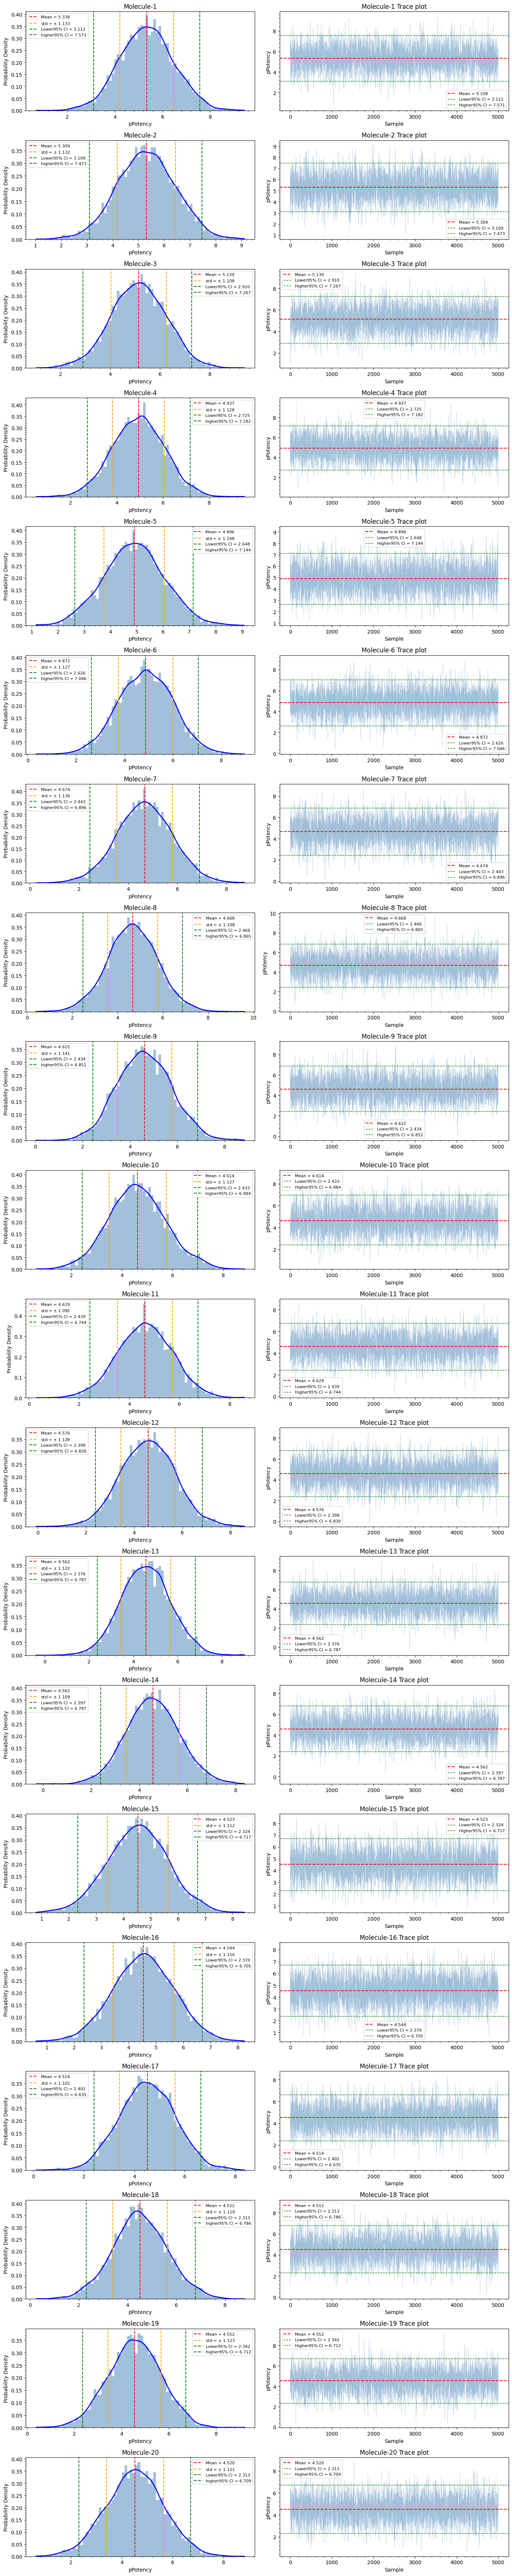

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_potency_from_draws(pred_df, feat_df, art, n=5, n_samples=5000):
    macaw_cols = [c for c in feat_df.columns if c.startswith('MACAW_')]

    merged = (
        pred_df.nlargest(n, 'pPotency_prediction')
               .merge(feat_df[['SMILES', *macaw_cols]], on='SMILES', how='inner')
    )
    if merged.empty:
        raise ValueError("None of the top‑n molecules have matching MACAW features.")

    fig, axes = plt.subplots(len(merged), 2, figsize=(14, 3.5 * len(merged)), squeeze=False)

    for i, (_, row) in enumerate(merged.iterrows()):
        x = row[macaw_cols].to_numpy(dtype=float).reshape(1, -1)

        raw_draws = art.post_pred_draws(x, n_samples=n_samples)
        draws = np.asarray(raw_draws).ravel()
        if draws.size < 2:
            print(f"Skipping {row['SMILES']} (not enough posterior samples).")
            continue

        mean = draws.mean()
        std = draws.std()
        lower_95, upper_95 = np.percentile(draws, [2.5, 97.5])

        

        ax_dist = axes[i, 0]
        ax_dist.hist(draws, bins=min(80, len(draws)//2 or 1), density=True,
                     alpha=0.5, color='steelblue')
        try:
            kde = gaussian_kde(draws)
            x_range = np.linspace(draws.min(), draws.max(), 500)
            ax_dist.plot(x_range, kde(x_range), 'b-', lw=2)
        except np.linalg.LinAlgError:
            pass  # KDE fails when draws have zero variance
        ax_dist.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.3f}')
        ax_dist.axvline(mean - std, color='orange', linestyle='--', lw=1.5)
        ax_dist.axvline(mean + std, color='orange', linestyle='--', lw=1.5, label=fr'std = $\pm$ {std:.3f}')
        ax_dist.axvline(lower_95, color='green', linestyle='--', label=f'Lower95% CI = {lower_95:.3f}')
        ax_dist.axvline(upper_95, color='green', linestyle='--', label=f'higher95% CI = {upper_95:.3f}')
        ax_dist.set_xlabel('pPotency')
        ax_dist.set_ylabel('Probability Density')
        ax_dist.set_title(f"Molecule-{i+1}")
        

        

        ax_dist.legend(fontsize=8, frameon=True)
        ax_dist.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_dist.yaxis.set_minor_locator(AutoMinorLocator(5))

        ax_trace = axes[i, 1]
        ax_trace.plot(draws, alpha=0.5, lw=0.3, color='steelblue')
        ax_trace.axhline(mean, color='red', linestyle='--', lw=1.5, label=f'Mean = {mean:.3f}')
        ax_trace.axhline(lower_95, color='green', linestyle='--', lw=1, label=f'Lower95% CI = {lower_95:.3f}')
        ax_trace.axhline(upper_95, color='green', linestyle='--', lw=1, label=f'Higher95% CI = {upper_95:.3f}')
        ax_trace.set_xlabel('Sample')
        ax_trace.set_ylabel('pPotency')
        ax_trace.set_title(f"Molecule-{i+1} Trace plot")
        ax_trace.legend(fontsize=8, frameon=True)
        ax_trace.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_trace.yaxis.set_minor_locator(AutoMinorLocator(5))

        print(f"Molecule {i+1}: mean={mean:.3f}, std={std:.3f}, "
              f"95% CI=[{lower_95:.3f}, {upper_95:.3f}], "
              f"IC50={10**(-mean)*1e6:.4f} µM")

    plt.tight_layout()
    plt.savefig(os.path.join(saveDir, "BacillusAnthracis_basidalinOnly_ARTprobability.png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(saveDir, "BacillusAnthracis_basidalinOnly_ARTprobability.pdf"), dpi=300, bbox_inches="tight")
    plt.show()

# plot potency of top 20 recomended molecules
plot_potency_from_draws(
    pred_df=BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_ARTprediction,
    feat_df=BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_wMACAW,
    art=art,
    n=20,
    n_samples=5000
)


### 4.5 FDA approved Antibiotic from `Drugbank` : Find external validation with pre-trained `ART` models

In [86]:
def canonicalize(smi):
    mol = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(mol) if mol else smi

# Load DORAnet generated molecules
BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_wMACAW = pd.read_csv(
    saveDir + "/BacillusAnthracisData_Drugbnk_FDAapproved_Antibiotic_wMACAW.csv")

total_before = len(BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_wMACAW)
print(f"Total DORAnet generated molecules before removing training set molecules: {total_before}")

# Training set stats
total_training_rows = len(BacillusAnthracisData_allDB_wMACAW)
unique_training_smiles = BacillusAnthracisData_allDB_wMACAW['Smiles'].nunique()
duplicate_training_smiles = BacillusAnthracisData_allDB_wMACAW['Smiles'].duplicated().sum()
print(f"Total training set SMILES: {total_training_rows}")
print(f"Unique training set SMILES: {unique_training_smiles}")
print(f"Duplicate training set SMILES: {duplicate_training_smiles}")

# Canonicalize training SMILES for consistent matching
training_smiles_set = set(BacillusAnthracisData_allDB_wMACAW['Smiles'].apply(canonicalize))
print(f"Unique canonical training SMILES: {len(training_smiles_set)}")

# Canonicalize DORAnet SMILES and remove matches
BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_wMACAW['canonical_SMILES'] = \
    BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_wMACAW['smiles'].apply(canonicalize)

BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_wMACAW = \
    BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_wMACAW[
        ~BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_wMACAW['canonical_SMILES'].isin(training_smiles_set)
    ].drop(columns=['canonical_SMILES']).reset_index(drop=True)

total_after = len(BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_wMACAW)
print(f"\nTraining set molecules found and removed: {total_before - total_after}")
print(f"Total DORAnet generated molecules for external validation: {total_after}")

BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_wMACAW

Total DORAnet generated molecules before removing training set molecules: 154
Total training set SMILES: 4081
Unique training set SMILES: 1647
Duplicate training set SMILES: 2434
Unique canonical training SMILES: 1647

Training set molecules found and removed: 22
Total DORAnet generated molecules for external validation: 132


,Unnamed: 0,smiles,ATC_code,Drug_Type,molecular_weight,logP,hydrogen_bond_acceptors,hydrogen_bond_donors,Lipinski,QED,...,MACAW_81,MACAW_82,MACAW_83,MACAW_84,MACAW_85,MACAW_86,MACAW_87,MACAW_88,MACAW_89,MACAW_90
0,0,NCC[C@H](O)C(=O)N[C@@H]1C[C@H](N)[C@@H](O[C@H]...,J01GB;J01RA,antibiotic,585.608,-8.42420,17,13,1.0,0.113064,...,0.004945,-0.018550,-0.011705,-0.015433,-0.034434,-0.019327,0.025629,0.024172,0.026561,0.014444
1,1,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](N)c3ccc(O)cc3)...,J01CA;J01CR,antibiotic,365.411,0.02370,6,4,4.0,0.553032,...,0.002578,0.020726,0.011753,0.011653,0.004072,-0.004949,0.025887,0.060284,-0.019935,0.000552
2,4,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](NC(=O)N3CCNC3=...,J01CA;J01CR,antibiotic,461.500,0.09420,6,4,4.0,0.454446,...,-0.026230,0.022725,0.000014,0.045660,0.012897,-0.016210,-0.018999,0.002083,0.026202,0.012985
3,5,C[C@H]1[C@H](NC(=O)/C(=N\OC(C)(C)C(=O)O)c2csc(...,J01DF,antibiotic,435.440,-2.22390,10,3,4.0,0.183042,...,0.012710,0.036393,0.017889,-0.012242,-0.015195,0.051287,0.000800,-0.001720,0.018931,0.000724
4,6,CCOC(=O)OC(C)OC(=O)[C@@H]1N2C(=O)[C@@H](NC(=O)...,J01CA;J01CR,antibiotic,465.528,1.29580,9,2,4.0,0.346579,...,-0.009253,0.002848,0.031117,-0.011431,0.009197,-0.010347,0.026021,0.002676,-0.006714,0.020742
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,146,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,J01AA,antibiotic,585.658,0.51320,11,7,1.0,0.180875,...,-0.037128,0.062961,0.006992,-0.021226,0.001537,0.003962,-0.026371,-0.032462,0.038779,0.021442
128,147,CCS(=O)(=O)CCn1c([N+](=O)[O-])cnc1C,J01RA;J01XD,antibiotic,247.276,0.53442,6,0,4.0,0.558464,...,-0.003287,-0.005639,-0.008070,0.000451,-0.009458,0.013884,0.050219,0.029420,0.013399,-0.019835
129,150,CO[C@H]1C[C@H](O[C@H]2[C@H](C)[C@@H](O[C@@H]3O...,J01FA,antibiotic,813.979,3.62090,16,0,2.0,0.186700,...,0.007489,0.008482,-0.011404,-0.021657,0.000231,-0.005975,-0.001405,-0.031596,-0.034877,-0.004269
130,151,N[C@@H]1[C@H]2CN(c3nc4c(cc3F)c(=O)c(C(=O)O)cn4...,J01MA,antibiotic,416.359,1.89450,6,2,4.0,0.676419,...,0.014234,-0.027752,-0.027615,0.009131,-0.009639,-0.011373,0.014708,0.034145,-0.023842,-0.008594


In [87]:
macaw_columns = [col for col in BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_wMACAW.columns if col.startswith('MACAW_')]
smiLib = BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_wMACAW[macaw_columns].values

### Get predictions with uncertainty using ART's post_pred_stats

In [88]:
# Pass X1_lib (features)
mean, std = art.post_pred_stats(smiLib)

# Now use these for your results
BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_ARTprediction = BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_wMACAW[['smiles']].copy()
BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_ARTprediction['pPotency_prediction'] = mean
BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_ARTprediction['pPotency_std'] = std

# Calculate 95% Confidence Intervals
BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_ARTprediction['pPotency_lower_95CI'] = mean - 1.96 * std
BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_ARTprediction['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_ARTprediction['IC50(M)_prediction'] = 10 ** (-mean)
BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_ARTprediction['IC50(M)_lower_95CI'] = 10 ** (-BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_ARTprediction['pPotency_upper_95CI'])
BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_ARTprediction['IC50(M)_upper_95CI'] = 10 ** (-BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_ARTprediction['pPotency_lower_95CI'])

# Select and save results
BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_ARTprediction = BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_ARTprediction.filter(
    items=["smiles", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

# PRE-SAVE: merge ART predictions with wMACAW on common smiles and drop MACAW columns
merged = pd.merge(
    BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_ARTprediction,
    BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_wMACAW,
    on="smiles",
    how="inner",
    suffixes=("_art","_macaw")
)

# Drop any column whose name contains 'MACAW'
merged = merged.loc[:, ~merged.columns.str.contains('MACAW')]

# Use the merged result as the ART prediction dataframe for saving
BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_ARTprediction = merged

BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_ARTprediction.to_csv(os.path.join(saveDir + "/BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_ARTprediction.csv"), index=False)
BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_ARTprediction[['smiles']].to_csv(os.path.join(saveDir + "/BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_ARTprediction_SMILES.csv"), index=False)
print(f"Predictions saved with uncertainty estimates")
BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_ARTprediction

Predictions saved with uncertainty estimates


,smiles,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,Unnamed: 0,ATC_code,...,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile,source_DataBase
0,NCC[C@H](O)C(=O)N[C@@H]1C[C@H](N)[C@@H](O[C@H]...,3.525954,1.119518,1.331698,5.720210,0.000298,1.904541e-06,0.046591,0,J01GB;J01RA,...,50.213261,31.136099,50.756107,2.132610,8.103916,6.397829,7.095774,91.779760,4.885615,FDA_Antibiotics
1,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](N)c3ccc(O)cc3)...,4.987345,1.120375,2.791410,7.183280,0.000010,6.557220e-08,0.001617,1,J01CA;J01CR,...,21.946491,39.278790,35.789066,14.618069,19.271035,13.609926,31.174874,70.104692,40.248158,FDA_Antibiotics
2,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](NC(=O)N3CCNC3=...,3.442877,1.119518,1.248620,5.637133,0.000361,2.306042e-06,0.056413,4,J01CA;J01CR,...,17.526173,74.059713,39.007367,18.960838,28.227995,14.385421,55.292749,51.337728,55.409073,FDA_Antibiotics
3,C[C@H]1[C@H](NC(=O)/C(=N\OC(C)(C)C(=O)O)c2csc(...,3.786489,1.118681,1.593873,5.979105,0.000163,1.049289e-06,0.025476,5,J01DF,...,9.461031,29.701435,34.044203,8.646762,40.209383,0.736720,30.981000,80.496316,78.480031,FDA_Antibiotics
4,CCOC(=O)OC(C)OC(=O)[C@@H]1N2C(=O)[C@@H](NC(=O)...,3.794162,1.118931,1.601058,5.987267,0.000161,1.029753e-06,0.025058,6,J01CA;J01CR,...,90.500194,97.867390,6.514153,51.647926,62.659946,60.992633,50.290810,52.307096,77.665762,FDA_Antibiotics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,4.309461,1.118857,2.116502,6.502420,0.000049,3.144704e-07,0.007647,146,J01AA,...,22.721985,83.171772,56.533540,23.768903,59.480419,24.660721,27.607600,60.488561,79.875921,FDA_Antibiotics
128,CCS(=O)(=O)CCn1c([N+](=O)[O-])cnc1C,4.424298,1.118918,2.231218,6.617377,0.000038,2.413365e-07,0.005872,147,J01RA;J01XD,...,14.850717,44.203180,26.483133,36.913532,13.105855,17.603722,19.464909,70.957736,66.072121,FDA_Antibiotics
129,CO[C@H]1C[C@H](O[C@H]2[C@H](C)[C@@H](O[C@@H]3O...,2.276538,1.125678,0.070209,4.482867,0.005290,3.289523e-05,0.850729,150,J01FA,...,92.400155,83.210547,74.408686,73.284219,76.424971,62.349748,49.864288,31.213649,88.677782,FDA_Antibiotics
130,N[C@@H]1[C@H]2CN(c3nc4c(cc3F)c(=O)c(C(=O)O)cn4...,3.073553,1.126205,0.866192,5.280915,0.000844,5.237026e-06,0.136084,151,J01MA,...,22.024040,7.599845,48.933695,34.005428,65.451725,24.040326,30.942226,20.240403,20.744475,FDA_Antibiotics


### Plot prediction probability

Molecule 1: mean=5.938, std=1.111, 95% CI=[3.756, 8.120], IC50=1.1532 µM
Molecule 2: mean=5.292, std=1.111, 95% CI=[3.156, 7.400], IC50=5.1058 µM
Molecule 3: mean=5.258, std=1.129, 95% CI=[3.048, 7.476], IC50=5.5205 µM
Molecule 4: mean=4.980, std=1.118, 95% CI=[2.714, 7.165], IC50=10.4654 µM
Molecule 5: mean=4.958, std=1.124, 95% CI=[2.755, 7.219], IC50=11.0229 µM
Molecule 6: mean=4.927, std=1.119, 95% CI=[2.708, 7.081], IC50=11.8269 µM
Molecule 7: mean=4.930, std=1.126, 95% CI=[2.717, 7.095], IC50=11.7596 µM
Molecule 8: mean=4.737, std=1.112, 95% CI=[2.551, 6.925], IC50=18.3382 µM
Molecule 9: mean=4.646, std=1.124, 95% CI=[2.424, 6.893], IC50=22.6030 µM
Molecule 10: mean=4.653, std=1.126, 95% CI=[2.492, 6.842], IC50=22.2268 µM
Molecule 11: mean=4.644, std=1.128, 95% CI=[2.407, 6.859], IC50=22.6870 µM
Molecule 12: mean=4.515, std=1.126, 95% CI=[2.306, 6.752], IC50=30.5700 µM
Molecule 13: mean=4.447, std=1.123, 95% CI=[2.196, 6.665], IC50=35.6943 µM
Molecule 14: mean=4.422, std=1.115, 9

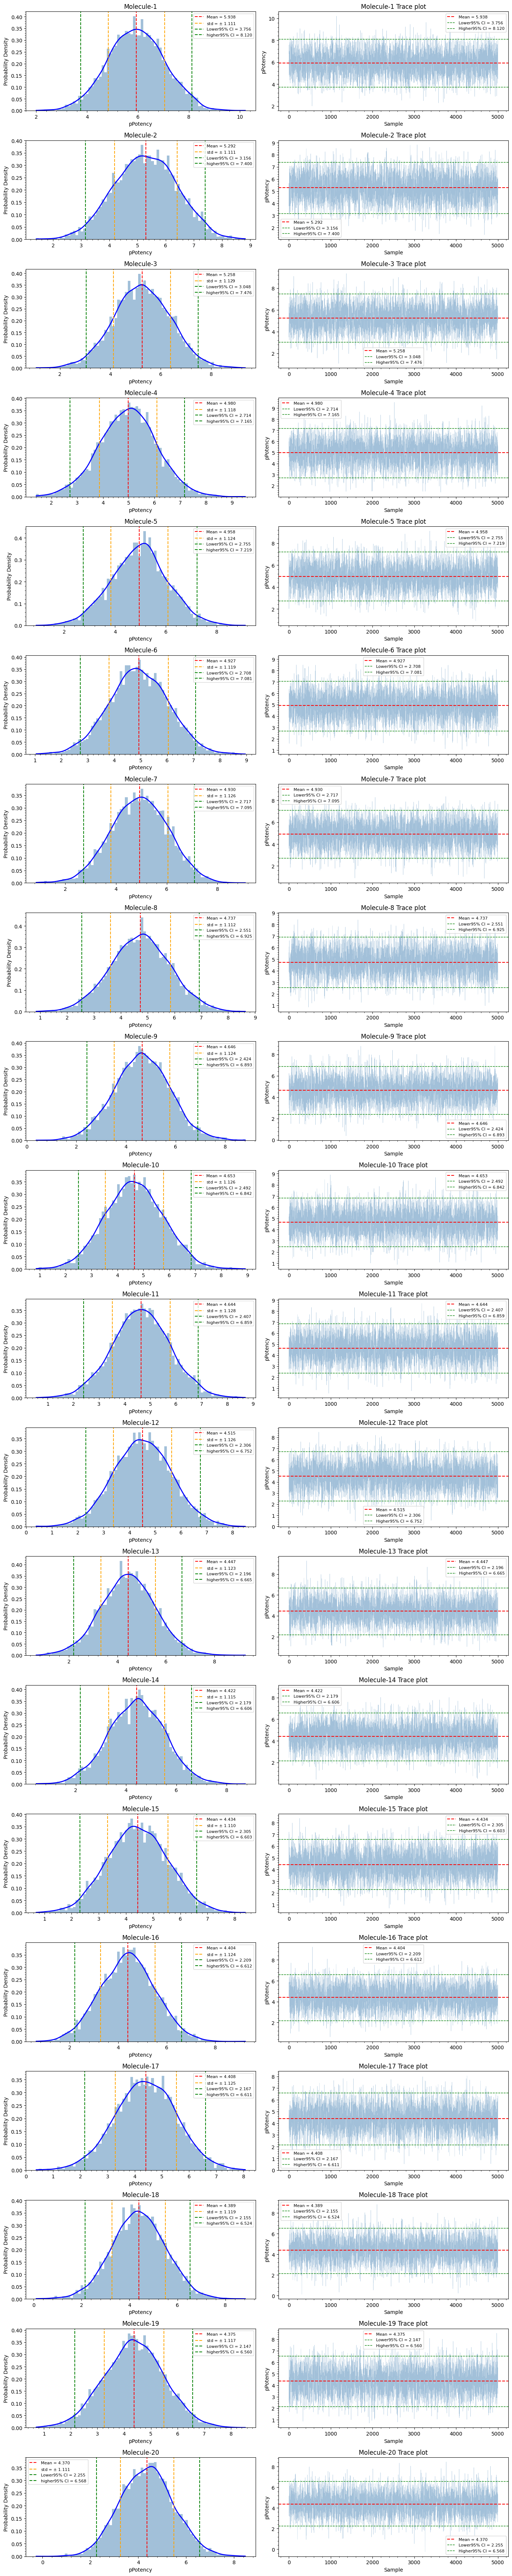

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_potency_from_draws(pred_df, feat_df, art, n=5, n_samples=5000):
    macaw_cols = [c for c in feat_df.columns if c.startswith('MACAW_')]

    merged = (
        pred_df.nlargest(n, 'pPotency_prediction')
               .merge(feat_df[['smiles', *macaw_cols]], on='smiles', how='inner')
    )
    if merged.empty:
        raise ValueError("None of the top‑n molecules have matching MACAW features.")

    fig, axes = plt.subplots(len(merged), 2, figsize=(14, 3.5 * len(merged)), squeeze=False)

    for i, (_, row) in enumerate(merged.iterrows()):
        x = row[macaw_cols].to_numpy(dtype=float).reshape(1, -1)

        raw_draws = art.post_pred_draws(x, n_samples=n_samples)
        draws = np.asarray(raw_draws).ravel()
        if draws.size < 2:
            print(f"Skipping {row['smiles']} (not enough posterior samples).")
            continue

        mean = draws.mean()
        std = draws.std()
        lower_95, upper_95 = np.percentile(draws, [2.5, 97.5])

        

        ax_dist = axes[i, 0]
        ax_dist.hist(draws, bins=min(80, len(draws)//2 or 1), density=True,
                     alpha=0.5, color='steelblue')
        try:
            kde = gaussian_kde(draws)
            x_range = np.linspace(draws.min(), draws.max(), 500)
            ax_dist.plot(x_range, kde(x_range), 'b-', lw=2)
        except np.linalg.LinAlgError:
            pass  # KDE fails when draws have zero variance
        ax_dist.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.3f}')
        ax_dist.axvline(mean - std, color='orange', linestyle='--', lw=1.5)
        ax_dist.axvline(mean + std, color='orange', linestyle='--', lw=1.5, label=fr'std = $\pm$ {std:.3f}')
        ax_dist.axvline(lower_95, color='green', linestyle='--', label=f'Lower95% CI = {lower_95:.3f}')
        ax_dist.axvline(upper_95, color='green', linestyle='--', label=f'higher95% CI = {upper_95:.3f}')
        ax_dist.set_xlabel('pPotency')
        ax_dist.set_ylabel('Probability Density')
        ax_dist.set_title(f"Molecule-{i+1}")
        

        

        ax_dist.legend(fontsize=8, frameon=True)
        ax_dist.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_dist.yaxis.set_minor_locator(AutoMinorLocator(5))

        ax_trace = axes[i, 1]
        ax_trace.plot(draws, alpha=0.5, lw=0.3, color='steelblue')
        ax_trace.axhline(mean, color='red', linestyle='--', lw=1.5, label=f'Mean = {mean:.3f}')
        ax_trace.axhline(lower_95, color='green', linestyle='--', lw=1, label=f'Lower95% CI = {lower_95:.3f}')
        ax_trace.axhline(upper_95, color='green', linestyle='--', lw=1, label=f'Higher95% CI = {upper_95:.3f}')
        ax_trace.set_xlabel('Sample')
        ax_trace.set_ylabel('pPotency')
        ax_trace.set_title(f"Molecule-{i+1} Trace plot")
        ax_trace.legend(fontsize=8, frameon=True)
        ax_trace.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_trace.yaxis.set_minor_locator(AutoMinorLocator(5))

        print(f"Molecule {i+1}: mean={mean:.3f}, std={std:.3f}, "
              f"95% CI=[{lower_95:.3f}, {upper_95:.3f}], "
              f"IC50={10**(-mean)*1e6:.4f} µM")

    plt.tight_layout()
    plt.savefig(os.path.join(saveDir, "BacillusAnthracis_Drugbnk_FDAapproved_ARTprobability.png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(saveDir, "BacillusAnthracis_Drugbnk_FDAapproved_ARTprobability.pdf"), dpi=300, bbox_inches="tight")
    plt.show()

# plot potency of top 20 recomended molecules
plot_potency_from_draws(
    pred_df=BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_ARTprediction,
    feat_df=BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_wMACAW,
    art=art,
    n=20,
    n_samples=5000
)
